In [10]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [11]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
FIELDVARS  = CONFIGS['experiments']['sr']['runs']['sr_atm']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
SPLIT      = 'test'
MINCUBESAMPLES = 100

SRFUNCTIONS = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'sin':np.sin,'cos':np.cos,'max':np.maximum,'min':np.minimum,
    '_safepow':lambda a,b:np.abs(a)**b}

import re
def _prepare_form(form):
    return re.sub(r'(\w+)\^(\w+)',r'_safepow(\1,\2)',form)

def eval_form(form,columns,constants):
    ns = dict(SRFUNCTIONS,__builtins__={})
    ns.update(columns)
    ns.update(constants)
    out = eval(_prepare_form(form),ns)
    if np.ndim(out)==0:
        n = len(next(v for v in columns.values() if hasattr(v,'__len__')))
        out = np.full(n,float(out))
    return np.asarray(out,dtype=float)

In [12]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
MEAN = STATS['tp_mean']
STD  = STATS['tp_std']
ZMIN = (0.0 - MEAN) / STD

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']
    nsig  = ds.sizes.get('sig',1)
    dsig  = ds['dsig'].values
    fields = np.stack([ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS],axis=1)
    surfmask = ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig) if 'surfmask' in ds else None
    flat = lambda v: ds[v].transpose('time','lat','lon').values.ravel() if 'time' in ds[v].dims else np.tile(ds[v].values,(ntime,1,1)).ravel()
    lfraw = flat('lf')
    shfraw = flat('shf')
    lhfraw = flat('lhf')
    blraw = flat('bl') if 'bl' in ds else np.zeros(ntime*ds.sizes['lat']*ds.sizes['lon'])

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsraw = ds['tp'].transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds.k.values)
meankernel = np.mean(kernels,axis=0)
weighted = fields * meankernel[None,:,:] * dsig[None,None,:]
if surfmask is not None:
    weighted = weighted * surfmask[:,None,:]
integrals = weighted.sum(axis=2)
rhraw,thetaeraw,thetaestarraw = integrals[:,0],integrals[:,1],integrals[:,2]

valid = np.isfinite(rhraw) & np.isfinite(thetaeraw) & np.isfinite(thetaestarraw) & np.isfinite(obsraw)
rh,thetae,thetaestar = rhraw[valid],thetaeraw[valid],thetaestarraw[valid]
lf,shf,lhf = lfraw[valid],shfraw[valid],lhfraw[valid]
bl = blraw[valid]
obs = obsraw[valid]
landmask  = lf > 0.5
oceanmask = lf < 0.5
print(f'Loaded {valid.sum():,} valid samples ({landmask.sum():,} land, {oceanmask.sum():,} ocean)')

Loaded 1,437,408 valid samples (428,352 land, 1,009,056 ocean)


In [13]:
regdf = pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv'))
REGISTRY = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),
                              train_loss=row['train_loss'],valid_loss=row['valid_loss'])
             for _,row in regdf.iterrows()}
SRMODELS = CONFIGS['experiments']['sr']['optimizedeqs']
ORDER  = [name for name in SRMODELS if name in REGISTRY]
LABELS = {name:SRMODELS[name]['description'] for name in ORDER}
COLORS = {name:SRMODELS[name]['color'] for name in ORDER}

def get_columns(**overrides):
    cols = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,
            'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
    cols.update(overrides)
    for eqname,entry in REGISTRY.items():
        if eqname in overrides:
            continue
        cols[eqname] = eval_form(entry['form'],cols,entry['constants'])
    return cols

def predict_eq(name,columns):
    entry = REGISTRY[name]
    raw = eval_form(entry['form'],columns,entry['constants'])
    z = ZMIN + np.maximum(raw,0.0)
    return np.maximum(np.expm1(z * STD + MEAN),0.0)

print(f'Loaded {len(ORDER)} optimized equations: {[LABELS[n] for n in ORDER]}')

Loaded 4 optimized equations: ['SR-BL', 'SR-ATM', 'SR-SFC', 'SR-ALL']


In [14]:
BASEVARS = ['rh','thetae','thetaestar','lf','shf','lhf','bl']
NCUBES = [3,4,5,6,7]
MINCUBESAMPLES = 100

CONSTRAINTS = {
    'PC1':{
        'label':r'$\partial P/\partial \mathrm{B_L} \geq 0$',
        'target_var':'bl',
        'expected_sign':1,
        'equations':['sr_bl_eq']},
    'PC2':{
        'label':r'$\partial P/\partial \widehat{\mathrm{RH}} \geq 0$',
        'target_var':'rh',
        'expected_sign':1,
        'equations':['sr_atm_eq','sr_sfc_eq','sr_all_eq','sr_all_pc_eq']},
    'PC3':{
        'label':r'$\partial P/\partial \widehat{\theta_e} \geq 0$',
        'target_var':'thetae',
        'expected_sign':1,
        'equations':['sr_atm_eq','sr_sfc_eq','sr_all_eq','sr_all_pc_eq']},
    'PC4':{
        'label':r'$\partial P/\partial \widehat{\theta_e^*} \leq 0$',
        'target_var':'thetaestar',
        'expected_sign':-1,
        'equations':['sr_atm_eq','sr_sfc_eq','sr_all_eq','sr_all_pc_eq']}}

def calc_dz(eqname):
    '''Compute analytical partial derivatives dz/dx_i at every sample.'''
    if eqname == 'sr_bl_eq':
        c = REGISTRY['sr_bl_eq']['constants']
        return {'bl':3*(bl+c['a'])**2}
    atm = REGISTRY['sr_atm_eq']['constants']
    a_atm,b_atm,c_atm = atm['a'],atm['b'],atm['c']
    arg = thetae - b_atm*thetaestar - c_atm
    rh_branch = rh >= arg
    buoy_branch = ~rh_branch
    dz_drh = np.where(rh_branch,3*a_atm*rh**2,0.0)
    dz_dthetae_atm = np.where(buoy_branch,3*a_atm*arg**2,0.0)
    dz_dthetaestar = np.where(buoy_branch,-b_atm*3*a_atm*arg**2,0.0)
    if eqname == 'sr_atm_eq':
        return {'rh':dz_drh,'thetae':dz_dthetae_atm,'thetaestar':dz_dthetaestar}
    if eqname == 'sr_sfc_eq':
        return {'rh':dz_drh,'thetae':dz_dthetae_atm,'thetaestar':dz_dthetaestar}
    if eqname == 'sr_all_eq':
        c = REGISTRY['sr_all_eq']['constants']
        return {'rh':dz_drh,'thetae':dz_dthetae_atm+(c['b']-lf)**3,'thetaestar':dz_dthetaestar}
    if eqname == 'sr_all_pc_eq':
        c = REGISTRY['sr_all_pc_eq']['constants']
        return {'rh':dz_drh,'thetae':dz_dthetae_atm+(c['b']-lf)**3-(c['b']-1)**3,'thetaestar':dz_dthetaestar}
    raise ValueError(f'Unknown equation: {eqname}')

def data_cube_monotonicity_test(target_var,expected_sign,other_vars,ncubes,mask=None):
    '''Hypercube monotonicity test for ERA5 observations.'''
    featurevals = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,
                   'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
    targetvals = featurevals[target_var]
    othervalslist = [featurevals[v] for v in other_vars]
    nother = len(other_vars)
    if mask is None:
        mask = np.ones(len(targetvals),dtype=bool)
    edges = [np.linspace(np.percentile(v[mask],1),np.percentile(v[mask],99),ncubes+1) for v in othervalslist]
    bins  = [np.clip(np.digitize(v,e)-1,0,ncubes-1) for v,e in zip(othervalslist,edges)]
    nsatisfied,ntested = 0,0
    cubeidx = bins[0].copy()
    for i in range(1,nother):
        cubeidx = cubeidx * ncubes + bins[i]
    for cidx in range(ncubes**nother):
        sel = mask & (cubeidx == cidx)
        if sel.sum() < MINCUBESAMPLES:
            continue
        x,y = targetvals[sel],obs[sel]
        if len(x) < 2:
            continue
        xc = x - x.mean()
        slope = np.dot(xc,y) / (np.dot(xc,xc) + 1e-12)
        ntested += 1
        if (expected_sign >= 0 and slope >= 0) or (expected_sign < 0 and slope <= 0):
            nsatisfied += 1
    return nsatisfied,ntested

In [15]:
ERA5_CONSTRAINTS = {
    'PC1':{'target_var':'bl','expected_sign':1,'other_vars':[]},
    'PC2':{'target_var':'rh','expected_sign':1,'other_vars':['thetae','thetaestar']},
    'PC3':{'target_var':'thetae','expected_sign':1,'other_vars':['rh','thetaestar']},
    'PC4':{'target_var':'thetaestar','expected_sign':-1,'other_vars':['rh','thetae']}}

era5results = {}
for pcname,pc in ERA5_CONSTRAINTS.items():
    if not pc['other_vars']:
        xc = bl - bl.mean()
        slope = np.dot(xc,obs) / (np.dot(xc,xc) + 1e-12)
        era5results[pcname] = 100.0 if slope >= 0 else 0.0
    else:
        pcts = []
        for n in NCUBES:
            sat,tot = data_cube_monotonicity_test(pc['target_var'],pc['expected_sign'],pc['other_vars'],n)
            pcts.append(sat/max(tot,1)*100)
        era5results[pcname] = np.mean(pcts)

modelresults = {}
for name in ORDER:
    modelresults[name] = {}
    derivs = calc_dz(name)
    for pcname,pc in CONSTRAINTS.items():
        if name not in pc['equations']:
            modelresults[name][pcname] = np.nan
            continue
        dz = derivs[pc['target_var']]
        if pc['expected_sign'] >= 0:
            frac = np.mean(dz >= 0) * 100
        else:
            frac = np.mean(dz <= 0) * 100
        modelresults[name][pcname] = frac

for name in ORDER:
    label = LABELS[name]
    parts = []
    for pcname in CONSTRAINTS:
        val = modelresults[name][pcname]
        if np.isnan(val):
            parts.append(f'{pcname}=N/A')
        else:
            parts.append(f'{pcname}={val:.1f}%')
    print(f'{label}: {", ".join(parts)}')

SR-BL: PC1=100.0%, PC2=N/A, PC3=N/A, PC4=N/A
SR-ATM: PC1=N/A, PC2=100.0%, PC3=100.0%, PC4=100.0%
SR-SFC: PC1=N/A, PC2=100.0%, PC3=100.0%, PC4=100.0%
SR-ALL: PC1=N/A, PC2=100.0%, PC3=88.7%, PC4=100.0%


In [16]:
PCLABELS = {k:v['label'] for k,v in CONSTRAINTS.items()}

columns = {}
for pcname in CONSTRAINTS:
    header = PCLABELS[pcname]
    vals = [era5results.get(pcname,np.nan)]
    for name in ORDER:
        vals.append(modelresults[name][pcname])
    columns[header] = vals

index = ['ERA5'] + [LABELS[name] for name in ORDER]
df = pd.DataFrame(columns,index=index)
df.index.name = 'Source'

def fmt(v):
    if np.isnan(v):
        return ''
    return f'{v:.1f}%'

df.style.format(fmt).set_caption(
    f'Physical constraint satisfaction (%, {SPLIT} split). '
    f'ERA5 tested via hypercube binning; SR models via analytical derivatives at all samples.')

,$\partial P/\partial \mathrm{B_L} \geq 0$,$\partial P/\partial \widehat{\mathrm{RH}} \geq 0$,$\partial P/\partial \widehat{\theta_e} \geq 0$,$\partial P/\partial \widehat{\theta_e^*} \leq 0$
Source,,,,
ERA5,100.0%,87.2%,100.0%,100.0%
SR-BL,100.0%,,,
SR-ATM,,100.0%,100.0%,100.0%
SR-SFC,,100.0%,100.0%,100.0%
SR-ALL,,100.0%,88.7%,100.0%


In [ ]:
NCUBE = 5
pc = ERA5_CONSTRAINTS['PC2']
target_var = pc['target_var']
other_vars = pc['other_vars']

featurevals = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,
               'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
targetvals = featurevals[target_var]
othervalslist = [featurevals[v] for v in other_vars]
nother = len(other_vars)

cuberows = []
for region,mask in [('Land',landmask),('Ocean',oceanmask)]:
    edges = [np.linspace(np.percentile(v[mask],1),np.percentile(v[mask],99),NCUBE+1) for v in othervalslist]
    bins = [np.clip(np.digitize(v,e)-1,0,NCUBE-1) for v,e in zip(othervalslist,edges)]
    cubeidx = bins[0].copy()
    for i in range(1,nother):
        cubeidx = cubeidx * NCUBE + bins[i]
    for cidx in range(NCUBE**nother):
        sel = mask & (cubeidx == cidx)
        if sel.sum() < MINCUBESAMPLES:
            continue
        x,y = targetvals[sel],obs[sel]
        xc = x - x.mean()
        slope = np.dot(xc,y) / (np.dot(xc,xc) + 1e-12)
        cuberows.append({
            'region':region,
            'slope':slope,
            'satisfied':slope >= 0,
            'nsamples':int(sel.sum()),
            'rh_mean':rh[sel].mean(),
            'precip_mean':obs[sel].mean(),
            'stability':thetaestar[sel].mean() - thetae[sel].mean()})

cubedf = pd.DataFrame(cuberows)
ocean = cubedf[cubedf['region']=='Ocean']
land = cubedf[cubedf['region']=='Land']
print(f'Ocean cubes: {len(ocean)} ({ocean.satisfied.sum()} satisfy PC2, '
      f'{(~ocean.satisfied).sum()} violate)')
print(f'Land cubes:  {len(land)} ({land.satisfied.sum()} satisfy PC2, '
      f'{(~land.satisfied).sum()} violate)')

NameError: name 'ocean' is not defined

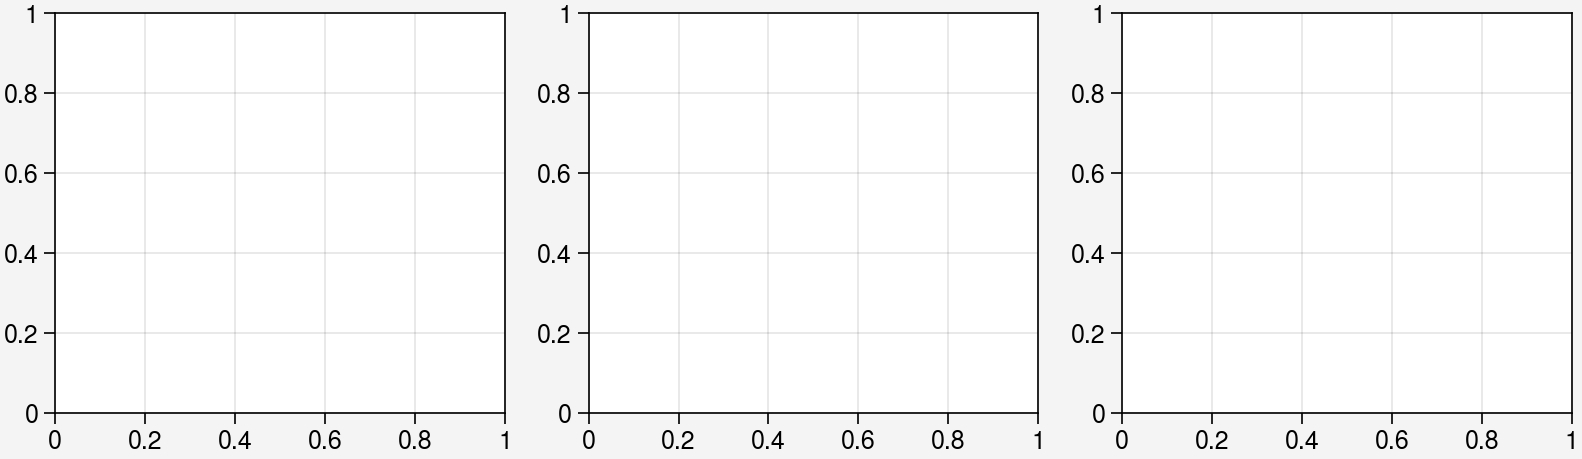

In [18]:
fig,axs = pplt.subplots(ncols=3,figwidth=8,refheight=2,sharey=False)

binshist = np.linspace(min(ocean['slope'].min(),-0.5),ocean['slope'].max(),30)
axs[0].hist(ocean[ocean['satisfied']]['slope'].values,bins=binshist,
            color='#2355a1',alpha=0.7,label=f'Satisfied (n={ocean.satisfied.sum()})')
axs[0].hist(ocean[~ocean['satisfied']]['slope'].values,bins=binshist,
            color='#C44E52',alpha=0.7,label=f'Violated (n={(~ocean.satisfied).sum()})')
axs[0].axvline(0,color='k',ls='--',lw=0.8)
axs[0].format(xlabel=r'$\partial P / \partial \widehat{\mathrm{RH}}$ slope',
              ylabel='Number of cubes',title='Slope magnitude')
axs[0].legend(loc='ur',fontsize=7,ncols=1)

axs[1].scatter(ocean[ocean['satisfied']]['rh_mean'],ocean[ocean['satisfied']]['stability'],
               c='#2355a1',s=20,alpha=0.6,label='Satisfied',zorder=2)
axs[1].scatter(ocean[~ocean['satisfied']]['rh_mean'],ocean[~ocean['satisfied']]['stability'],
               c='#C44E52',s=40,alpha=0.8,label='Violated',marker='x',zorder=3)
axs[1].format(xlabel=r'Cube mean $\widehat{\mathrm{RH}}$',
              ylabel=r'Cube mean $\widehat{\theta_e^*} - \widehat{\theta_e}$',
              title='Thermodynamic regime')
axs[1].legend(loc='ur',fontsize=7,ncols=1)

axs[2].scatter(ocean[ocean['satisfied']]['rh_mean'],ocean[ocean['satisfied']]['precip_mean'],
               c='#2355a1',s=20,alpha=0.6,label='Satisfied',zorder=2)
axs[2].scatter(ocean[~ocean['satisfied']]['rh_mean'],ocean[~ocean['satisfied']]['precip_mean'],
               c='#C44E52',s=40,alpha=0.8,label='Violated',marker='x',zorder=3)
axs[2].format(xlabel=r'Cube mean $\widehat{\mathrm{RH}}$',ylabel='Cube mean precip (mm)',
              title='Precipitation regime')
axs[2].legend(loc='ur',fontsize=7,ncols=1)

axs.format(abc=True,titleloc='l')
fig.save('../figs/fig_S2.jpg')